In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
df_top_10_significant = pd.read_csv('partikel_data_50000_rounded.csv')
#Generate new dataset which takes 50000 entries from df at random
#df_top_10_significant = df.sample(n=50000, random_state=42)
##Save the new dataset to a csv file
#df_sampled.to_csv('AppML_InitialProject_train_50000.csv', index=False)

In [7]:
variables = df_top_10_significant.columns

# Decide on which variables to use for input (X) and what defines the label (Y):
input_variables = variables[(variables != 'p_Truth_isElectron') & (variables != 'p_Truth_Energy')]
input_data      = df_top_10_significant[input_variables]
truth_data      = df_top_10_significant['p_Truth_isElectron']

In [8]:
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from sklearn.metrics import confusion_matrix
import lightgbm as lgb
from lightgbm import early_stopping
import time

start=time.time()

# Split data set into training and test set. We choose a 75:25 division here. 

# Dataset is shuffeled before the split (to avoid any ordering). By using a fixed
# random seed number (42), we can rerun and obtain the same result (for reproducibility!).
X_train, X_test, y_train, y_test = \
    train_test_split(input_data, truth_data, test_size=0.25, random_state=42)

# Feed the datasets to LightGBM:
lgb_train = lgb.Dataset(X_train, y_train)  # Training data
lgb_eval  = lgb.Dataset(X_test,  y_test, reference=lgb_train)

# Set parameters for LightGBM (known more generally as "hyper parameters"):
params = {
    'boosting_type': 'gbdt', # Traditional Gradient Boosting tree, we are combining many 'weak' learners here!
    'objective': 'binary',   # The outcome is binary, b-quark or not
    'num_leaves': 6,         # Set a maximum tree leaves to avoid overfitting
    'verbose': 1,            # Level of output. Can be set to -1 to suppress the output
}

# Train the model:
gbm = lgb.train(params,                             # General settings (defined above)
                lgb_train,                          # Data to use for training
                num_boost_round=1000,               # How many rounds for training
                valid_sets=lgb_eval,                # Data to use for validation
                callbacks=[early_stopping(20)])     # Stops if no improvement is seen in N=20 rounds.

# Make predictions.
# NOTE the difference between 'score' (continuous in ]0,1[) and 'predictions' (integer: 0 or 1):
# Also NOTE that you can choose where to set the threshold (here set to 0.1)


[LightGBM] [Info] Number of positive: 7845, number of negative: 29655
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002742 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2041
[LightGBM] [Info] Number of data points in the train set: 37500, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.209200 -> initscore=-1.329754
[LightGBM] [Info] Start training from score -1.329754
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[239]	valid_0's binary_logloss: 0.0963943
Early stopping, best iteration is:
[239]	valid_0's binary_logloss: 0.0963943


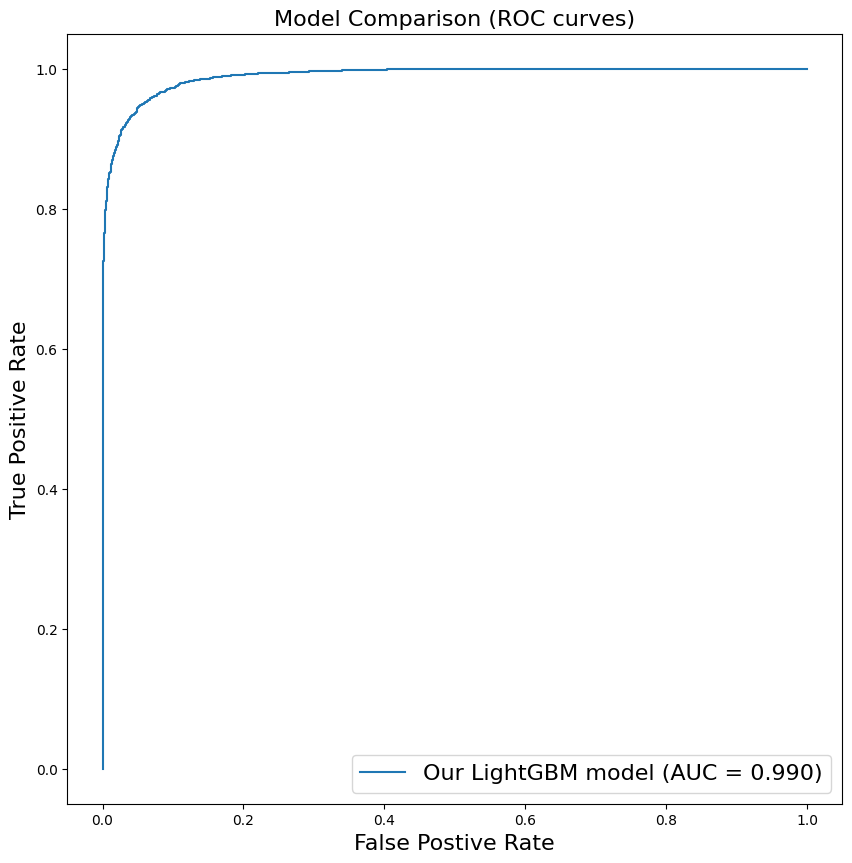

In [9]:
y_score = gbm.predict(X_test, num_iteration=gbm.best_iteration)  # Scores are floats in the range ]0,1[.

# Evaluate:
fpr, tpr, _ = roc_curve(y_test, y_score)                  # False/True Positive Rate for our model
#fpr_nnbjet, tpr_nnbjet, _ = roc_curve(y_test, benchmark_test)  # False/True Positive Rate for Aleph NNbjet

# We can now calculate the Area-Under-the-Curve (AUC) scores of these ROC-curves:
auc_score = auc(fpr,tpr)                        # This is the AUC score for our model
#auc_score_nnbjet = auc(fpr_nnbjet, tpr_nnbjet)  # This is the AUC score for Aleph NNbjet

# Let's plot the ROC curves for these results:
fig = plt.figure(figsize = [10,10])
plt.title('Model Comparison (ROC curves)', size = 16)
plt.plot(fpr, tpr, label=f'Our LightGBM model (AUC = {auc_score:5.3f})')
#plt.plot(fpr_nnbjet, tpr_nnbjet, label = f'Aleph NNbjet (AUC = {auc_score_nnbjet:5.3f})')
plt.legend(fontsize=16)
plt.xlabel('False Postive Rate', size=16)
plt.ylabel('True Positive Rate', size=16)
plt.show()

Plotting feature importances...


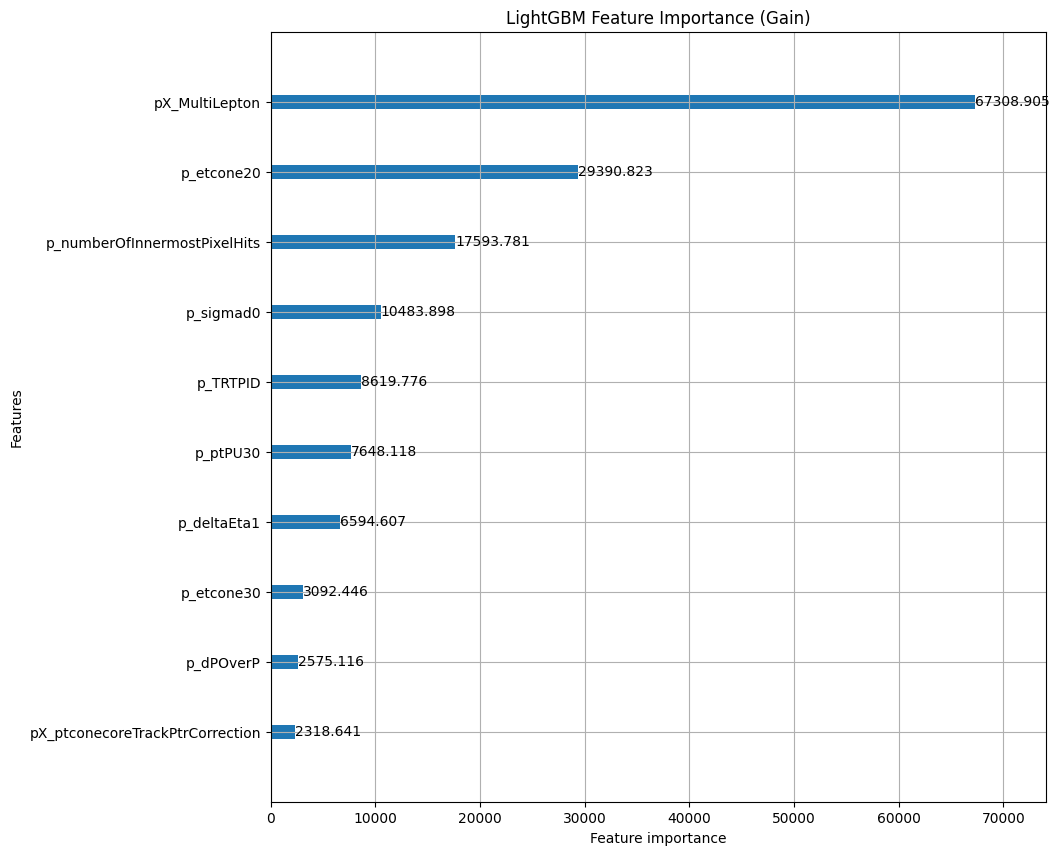

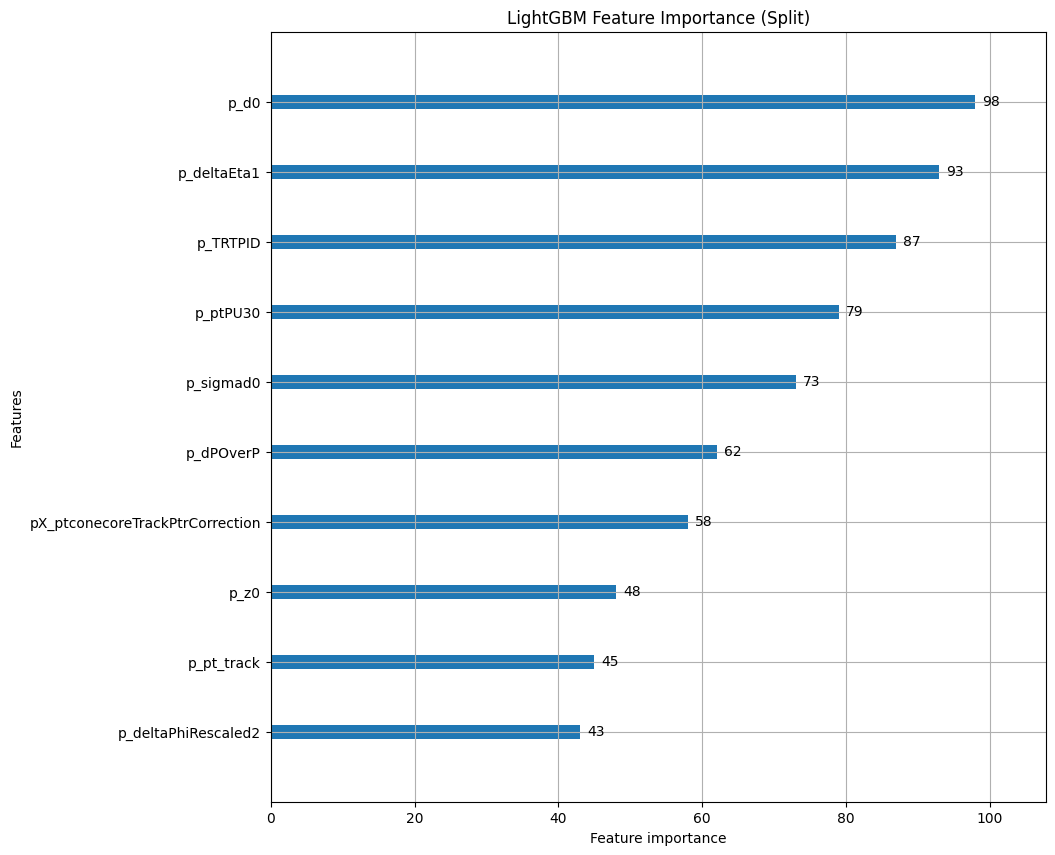

In [9]:
# Plot feature importance
print("Plotting feature importances...")
lgb.plot_importance(gbm, importance_type='gain', figsize=(10, 10), title='LightGBM Feature Importance (Gain)', max_num_features=10)
plt.show()

lgb.plot_importance(gbm, importance_type='split', figsize=(10, 10), title='LightGBM Feature Importance (Split)', max_num_features=10)
plt.show()

In [11]:
from sklearn.inspection import permutation_importance
gbm = lgb.LGBMRegressor()


# Calculate permutation importance
perm_importance = permutation_importance(gbm.fit(X_train, y_train), X_test, y_test, n_repeats=1, random_state=42)
sorted_idx = perm_importance.importances_mean.argsort()[::1]

c:\Users\beego\anaconda3\envs\AppML\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\beego\anaconda3\envs\AppML\Lib\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002244 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2041
[LightGBM] [Info] Number of data points in the train set: 37500, number of used features: 10
[LightGBM] [Info] Start training from score 0.209200


C:\Users\beego\AppData\Local\Temp\ipykernel_12416\2179622334.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(perm_importance.importances[sorted_idx][-25:].T, vert=False, labels=input_variables[sorted_idx][-25:])


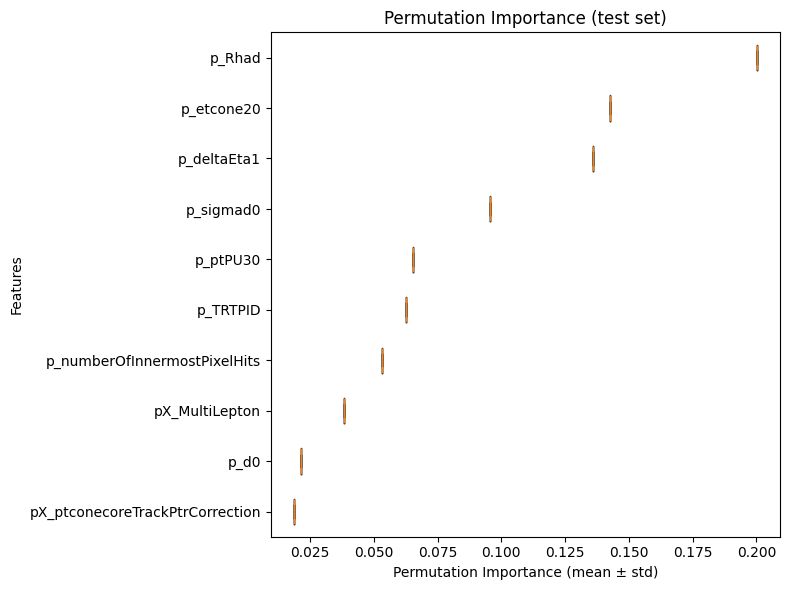

In [12]:

fig, ax = plt.subplots(figsize=(8, 6))
ax.boxplot(perm_importance.importances[sorted_idx][-25:].T, vert=False, labels=input_variables[sorted_idx][-25:])
ax.set_title("Permutation Importance (test set)")
ax.set_xlabel("Permutation Importance (mean ± std)")
ax.set_ylabel("Features")
plt.tight_layout()
plt.show()

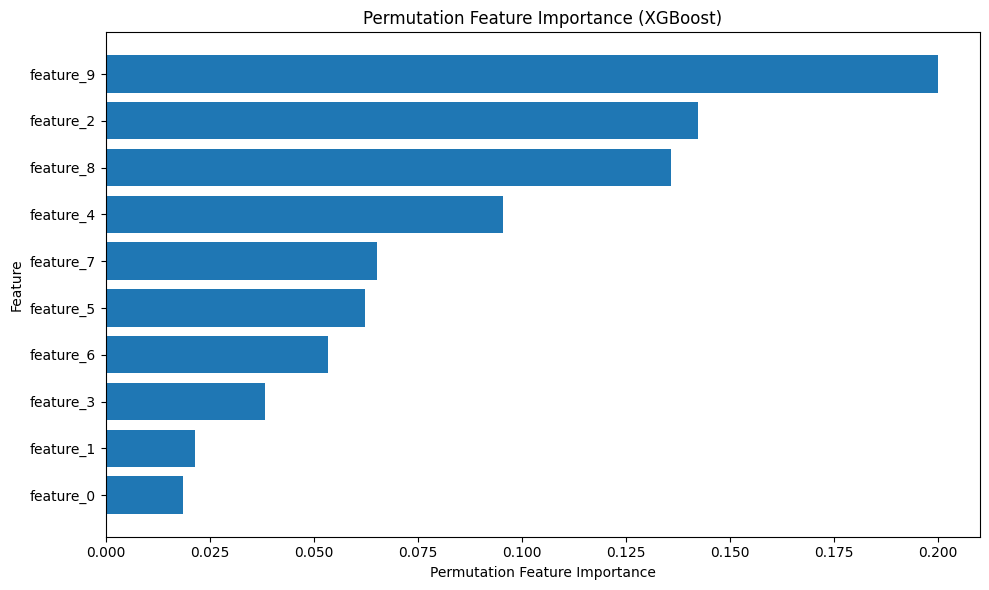

In [13]:
labels=input_variables[sorted_idx]
# Plot permutation feature importance
sorted_idx = perm_importance.importances_mean.argsort()
plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_idx))[-30:], (perm_importance.importances_mean[sorted_idx])[-30:], align='center')
plt.yticks(range(len(sorted_idx))[-30:], [f'feature_{i}' for i in sorted_idx[-30:]])
# plt.yticks(range(len(sorted_idx[-30:])), [f'{labels[i]}' for i in sorted_idx[-30:]])
plt.xlabel('Permutation Feature Importance')
plt.ylabel('Feature')
plt.title('Permutation Feature Importance (XGBoost)')
plt.tight_layout()
plt.show()

In [16]:
#Save a new dataset containing only the 10 most important features according to the permutation invariance test
top_10_indices = sorted_idx[-10:]
top_10_features = input_variables[top_10_indices]
df_top_10 = df_sampled[top_10_features]
#also add truth feature
df_top_10['p_Truth_isElectron'] = df_sampled['p_Truth_isElectron']
#Round all features to two non-zero decimal places
#df_top_10 = df_top_10.round(2)
#df_top_10.to_csv('AppML_InitialProject_train_top10features.csv', index=False)

C:\Users\beego\AppData\Local\Temp\ipykernel_7756\3679202798.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_top_10['p_Truth_isElectron'] = df_sampled['p_Truth_isElectron']


In [45]:
import math

def round_to_significant_figures(x, n):
    """
    Rounds a number x to n significant figures.
    """
    if x == 0:
        return 0
    if math.isnan(x):
        return x
    
    # Calculate the number of decimal places to round to
    # based on the number's magnitude (order of magnitude).
    order_of_magnitude = math.floor(math.log10(abs(x)))
    if order_of_magnitude > -1:
        decimal_places = 2
    else:
        decimal_places = 2 - 1 - order_of_magnitude
    
    return round(x, decimal_places)

# Create a new DataFrame with features rounded to 2 significant figures
# We use .copy() to avoid changing the original df_top_10
df_top_10_significant = df_top_10.copy()

# Apply the function to all columns except the truth label
feature_cols = [col for col in df_top_10_significant.columns if col != 'p_Truth_isElectron']
for col in feature_cols:
    df_top_10_significant[col] = df_top_10_significant[col].apply(lambda x: round_to_significant_figures(x, 2))


# Display the first few rows to see the result
print("Original DataFrame:")
print(df_top_10.head())
print("\nDataFrame rounded to 2 significant figures:")
print(df_top_10_significant.head())

# You can now save this new DataFrame if you wish:
df_top_10_significant.to_csv('partikel_data_50000_rounded.csv', index=False)


Original DataFrame:
        pX_ptconecoreTrackPtrCorrection      p_d0  p_etcone20  pX_MultiLepton  \
123137                        1330.2645 -0.110980    0.697966               0   
130504                       16315.0980  0.002749    1.195643               0   
31166                        44542.9400 -0.025469    0.028163               0   
26262                            0.0000  0.016783    0.013476               1   
64868                        19041.4450  0.033363    1.694580               0   

        p_sigmad0  p_TRTPID  p_numberOfInnermostPixelHits  p_ptPU30  \
123137   0.163434 -0.008453                             0  0.000000   
130504   0.020786 -0.000000                             2  0.000019   
31166    0.008116  0.477086                             1  0.000000   
26262    0.017662  0.195627                             1  0.000011   
64868    0.019369 -0.209522                             1  0.000027   

        p_deltaEta1    p_Rhad  p_Truth_isElectron  
123137     0.0

In [43]:
x = 11.2222
order_of_magnitude = math.floor(math.log10(abs(x)))
if order_of_magnitude > -1:
    decimal_places = 2
else:
    decimal_places = 2 - 1 - order_of_magnitude
print(decimal_places)
np.round(x,decimal_places)

2


np.float64(11.22)